# Mock-SBI validation figures

Five figures, in order:

1. theory `Cl` data vector at the fiducial point, with diagonal-covariance error bars
2. theory HMC vs theory SBI contours
3. the fiducial pasted Backlight maps (galaxies, y, kappa, tau)
4. the 128 design points over those contours
5. theory HMC vs theory SBI vs mock SBI

Every panel reads a saved artifact. Nothing is fitted or re-simulated here.

In [1]:
import json, pathlib, sys
import numpy as np, h5py, healpy as hp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

REPO = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")
sys.path.insert(0, str(REPO / "notebooks/SBI_validate"))
INF  = REPO / "data/SBI_validate/three_probe_inference"
MSBI = REPO / "data/SBI_validate/mock_sbi"

SPECTRA = ["gy", "gkappa", "gtau"]
SPEC_LABEL = {"gy": r"$g \times y$", "gkappa": r"$g \times \kappa_{\rm CMB}$",
              "gtau": r"$g \times \tau$"}
PARAMS = ["theta_ej_0", "alpha_nt", "mu_beta", "theta_co_0", "nu_theta_ej_M"]
LABELS = [r"$\theta_{\rm ej,0}$", r"$\alpha_{\rm nt}$", r"$\mu_\beta$",
          r"$\theta_{\rm co,0}$", r"$\nu_{\theta_{\rm ej},M}$"]
TRUTH  = np.array([2.0, 0.18, 0.6, 0.05, 0.0])
N_BAND = 14

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "axes.labelcolor": INK,
                     "xtick.color": INK2, "ytick.color": INK2, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

In [2]:
# !pip install healpy



## 1. Theory `Cl` at the fiducial point

`observation_selfconsistent.h5` is the noiseless analytic-theory prediction at
theta = [2.0, 0.18, 0.6, 0.05, 0.0]. Error bars are `sqrt(diag(C))` from the same file,
i.e. the frozen inference covariance.

gy       S/N per band  min   2.4   max  58.1   total   87.1
gkappa   S/N per band  min  16.1   max  25.2   total   81.2
gtau     S/N per band  min  11.7   max  28.0   total   81.3


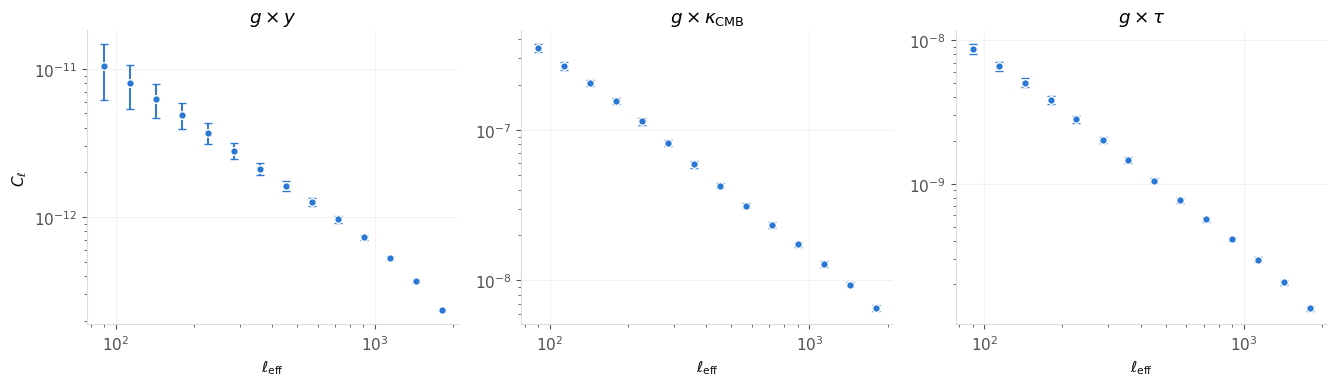

In [3]:
with h5py.File(INF / "observation_selfconsistent.h5", "r") as h:
    theory = np.asarray(h["data_vector"], float)
    cov    = np.asarray(h["covariance"], float)
    ell    = np.asarray(h["effective_ell"], float)
sigma = np.sqrt(np.diag(cov))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for k, (ax, s) in enumerate(zip(axes, SPECTRA)):
    sl = slice(N_BAND * k, N_BAND * (k + 1))
    ax.errorbar(ell, theory[sl], yerr=sigma[sl], fmt="o", ms=5.5, lw=1.4,
                capsize=3, color=BLUE, mec="white", mew=1.0)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\ell_{\rm eff}$"); ax.set_title(SPEC_LABEL[s])
    ax.grid(alpha=0.35, color=GRID)
axes[0].set_ylabel(r"$C_\ell$")
fig.tight_layout()

for k, s in enumerate(SPECTRA):
    sl = slice(N_BAND * k, N_BAND * (k + 1))
    snr = np.abs(theory[sl]) / sigma[sl]
    print(f"{s:<8} S/N per band  min {snr.min():5.1f}   max {snr.max():5.1f}   "
          f"total {np.sqrt((snr ** 2).sum()):6.1f}")

## 2. Theory HMC vs theory SBI

Both on the same noiseless self-consistent observation. Contours are 68% and 95% of the
2-D marginal, from a smoothed histogram of the samples.

In [4]:
LEVELS = (0.68, 0.95)
BINS_1D, SMOOTH_1D = 64, 2.4
BINS_2D, SMOOTH_2D = 44, 1.35

def levels_of(h):
    flat = np.sort(h.ravel())[::-1]
    c = np.cumsum(flat); c /= c[-1]
    return sorted({float(flat[min(int(np.searchsorted(c, f)), flat.size - 1)])
                   for f in LEVELS})

def triangle(chains, colors, names, points=None, truth=True, figsize=(11.2, 10.6)):
    """chains: list of (n, 5) sample arrays. points: optional (m, 5) to scatter."""
    n = 5
    lo, hi = np.empty(n), np.empty(n)
    for j in range(n):
        q = np.concatenate([np.percentile(c[:, j], [0.3, 99.7]) for c in chains])
        if points is not None:
            q = np.concatenate([q, [points[:, j].min(), points[:, j].max()]])
        pad = 0.06 * (q.max() - q.min())
        lo[j], hi[j] = q.min() - pad, q.max() + pad
    fig, axes = plt.subplots(n, n, figsize=figsize)
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if j > i:
                ax.axis("off"); continue
            if i == j:
                for c, col in zip(chains, colors):
                    cnt, e = np.histogram(c[:, j], bins=BINS_1D, range=(lo[j], hi[j]),
                                          density=True)
                    d = gaussian_filter(cnt, SMOOTH_1D)
                    ax.plot(0.5 * (e[:-1] + e[1:]), d / d.max(), color=col, lw=1.9)
                ax.set_ylim(0, 1.13); ax.set_yticks([])
                ax.spines["left"].set_visible(False)
            else:
                for k, (c, col) in enumerate(zip(chains, colors)):
                    h2, xe, ye = np.histogram2d(c[:, j], c[:, i], bins=BINS_2D,
                                                range=[[lo[j], hi[j]], [lo[i], hi[i]]])
                    h2 = gaussian_filter(h2.T, SMOOTH_2D)
                    if h2.max() <= 0: continue
                    lv = levels_of(h2)
                    xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
                    ax.contourf(xc, yc, h2, levels=lv + [h2.max() * 1.001],
                                colors=col, alpha=0.22, zorder=1 + k)
                    ax.contour(xc, yc, h2, levels=lv, colors=col, linewidths=1.5,
                               zorder=5 + k)
                if points is not None:
                    ax.plot(points[:, j], points[:, i], "o", ms=3.2, mfc="none",
                            mec=INK, mew=0.75, alpha=0.85, zorder=20)
                ax.set_ylim(lo[i], hi[i])
            if truth:
                ax.axvline(TRUTH[j], color=INK2, lw=0.9, ls=(0, (4, 2.5)), zorder=0)
                if i != j:
                    ax.axhline(TRUTH[i], color=INK2, lw=0.9, ls=(0, (4, 2.5)), zorder=0)
            ax.set_xlim(lo[j], hi[j])
            ax.xaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            if i != j: ax.yaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            ax.tick_params(labelsize=8.5)
            if i == n - 1: ax.set_xlabel(LABELS[j], fontsize=13)
            else:          ax.set_xticklabels([])
            if j == 0 and i > 0: ax.set_ylabel(LABELS[i], fontsize=13)
            elif j != 0:         ax.set_yticklabels([])
    handles = [Line2D([], [], color=c, lw=2.6, label=nm) for c, nm in zip(colors, names)]
    if points is not None:
        handles.append(Line2D([], [], color=INK, marker="o", ms=5, mfc="none", ls="none",
                              label="design points"))
    if truth:
        handles.append(Line2D([], [], color=INK2, lw=1.2, ls=(0, (4, 2.5)), label="truth"))
    fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.975, 0.965),
               frameon=False, fontsize=13.5, labelcolor=INK, handlelength=1.9)
    fig.subplots_adjust(left=0.085, right=0.985, top=0.985, bottom=0.075,
                        wspace=0.09, hspace=0.09)
    return fig

theory HMC 7,200 samples   theory SBI 40,000 samples


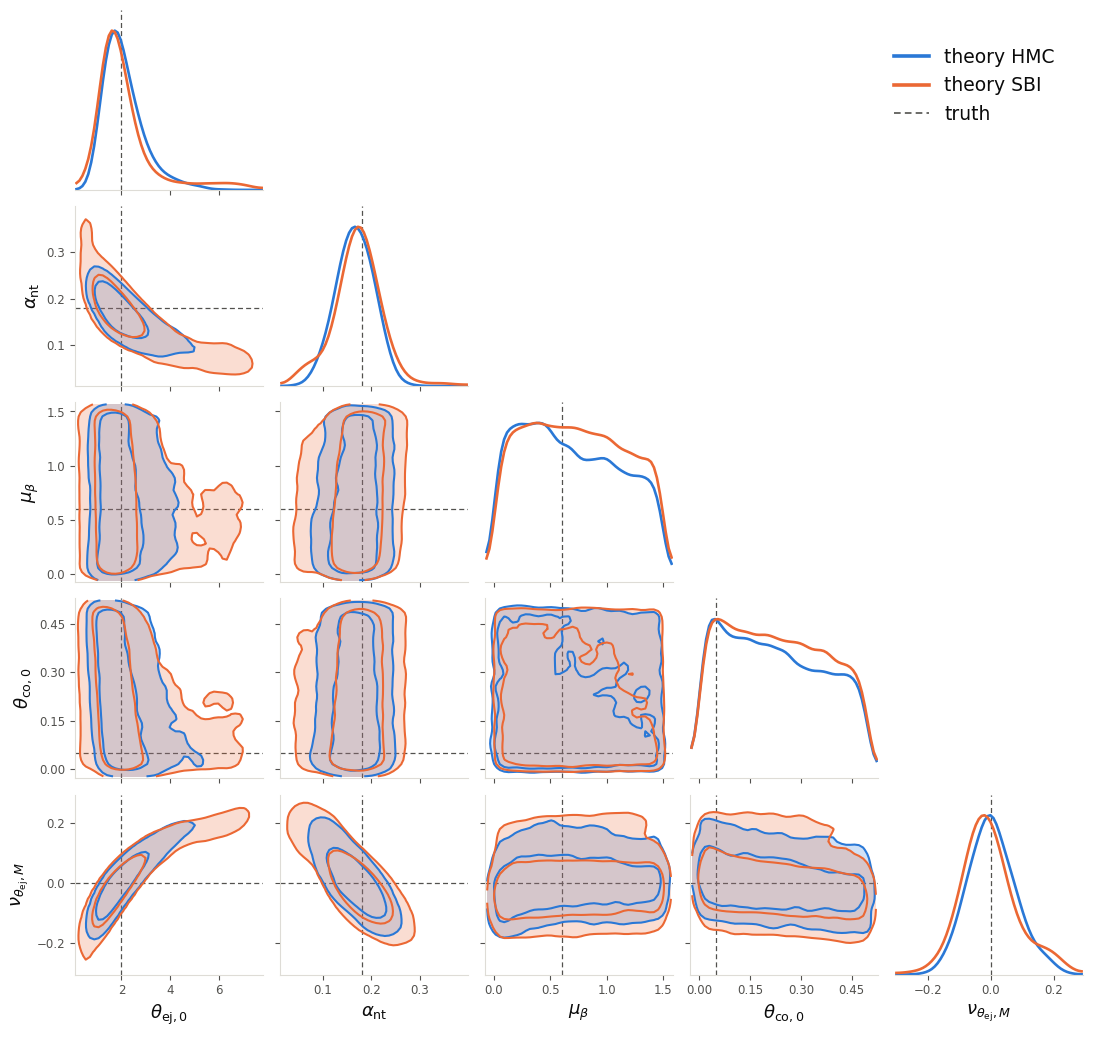

In [5]:
hraw = np.load(INF / "hmc_sc/run01/hmc_samples.npz")
hmc  = np.stack([np.asarray(hraw[f"sample_{p}"]).reshape(-1) for p in PARAMS], axis=1)
npe  = np.asarray(np.load(INF / "sbi_sc/run01/posterior_samples_round_4.npz")["theta"])
print(f"theory HMC {hmc.shape[0]:,} samples   theory SBI {npe.shape[0]:,} samples")

_ = triangle([hmc, npe], [BLUE, ORANGE], ["theory HMC", "theory SBI"])

## 3. Fiducial pasted Backlight maps

The paste at the fiducial point, nside 1024. `y`, `tau` and `kappa_CMB` are stored as maps;
the galaxy field is not (the per-point pastes run with `get_galmap: false`, since the galaxy
field is frozen across the five gas parameters), so it is binned from the 62.9M-row frozen
galaxy catalog in the same file and cached.

In [6]:
PASTE = (REPO / "data/SBI_validate/three_probe_mock/maps"
              / "c0000_z0p3_0p5_mmin5e11_cosh32_fast"
              / "abacus_pasted_maps_c0000_z0p3_0p5_mmin5e11_nside1024.h5")
GALCACHE = MSBI / "figures/fiducial_galaxy_counts.npz"

with h5py.File(PASTE, "r") as h:
    maps = {k: np.asarray(h[f"maps/{k}"], np.float64) for k in
            ("map_ymap", "map_tau", "map_kappa_cmb")}

g = np.load(GALCACHE)
counts = np.asarray(g["counts"], np.float64)
NSIDE = int(g["nside"])
observed = counts > 0
delta_g = np.full(counts.size, hp.UNSEEN)
delta_g[observed] = counts[observed] / counts[observed].mean() - 1.0
print(f"{int(g['n_valid']):,} valid galaxies   "
      f"{100 * observed.mean():.1f}% of the sphere occupied")

62,900,944 valid galaxies   96.9% of the sphere occupied


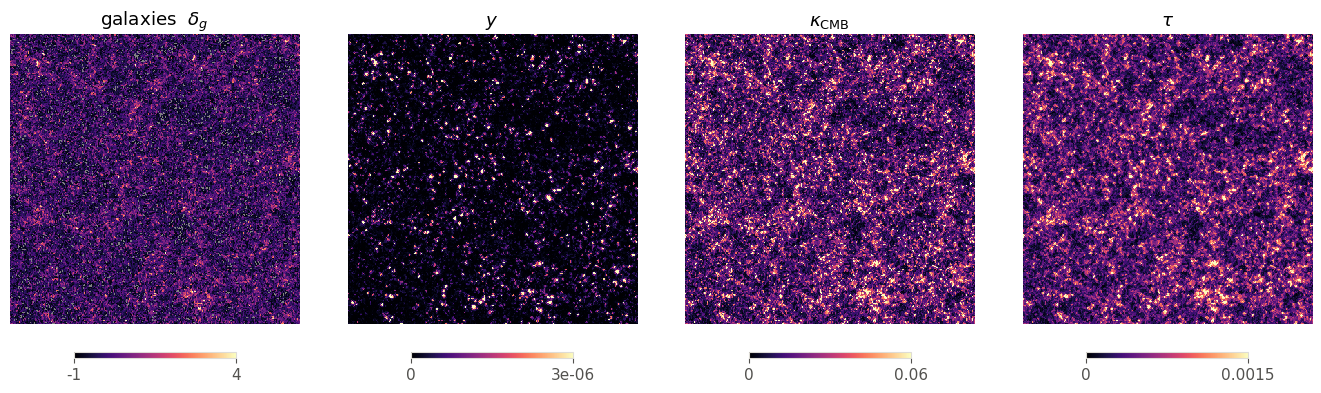

In [7]:
# One gnomview per field, on the same patch, so structure is comparable by eye.
LON, LAT, RESO, XSIZE = 20.0, -30.0, 2.2, 420
panels = [(delta_g, r"galaxies  $\delta_g$", -1.0, 4.0),
          (maps["map_ymap"], r"$y$", 0.0, 3e-6),
          (maps["map_kappa_cmb"], r"$\kappa_{\rm CMB}$", 0.0, 0.06),
          (maps["map_tau"], r"$\tau$", 0.0, 1.5e-3)]

fig = plt.figure(figsize=(13.5, 3.6))
for idx, (m, title, vmin, vmax) in enumerate(panels, start=1):
    hp.gnomview(m, rot=(LON, LAT), reso=RESO, xsize=XSIZE, min=vmin, max=vmax,
                title=title, cbar=True, notext=True, cmap="magma",
                sub=(1, 4, idx), fig=fig.number)

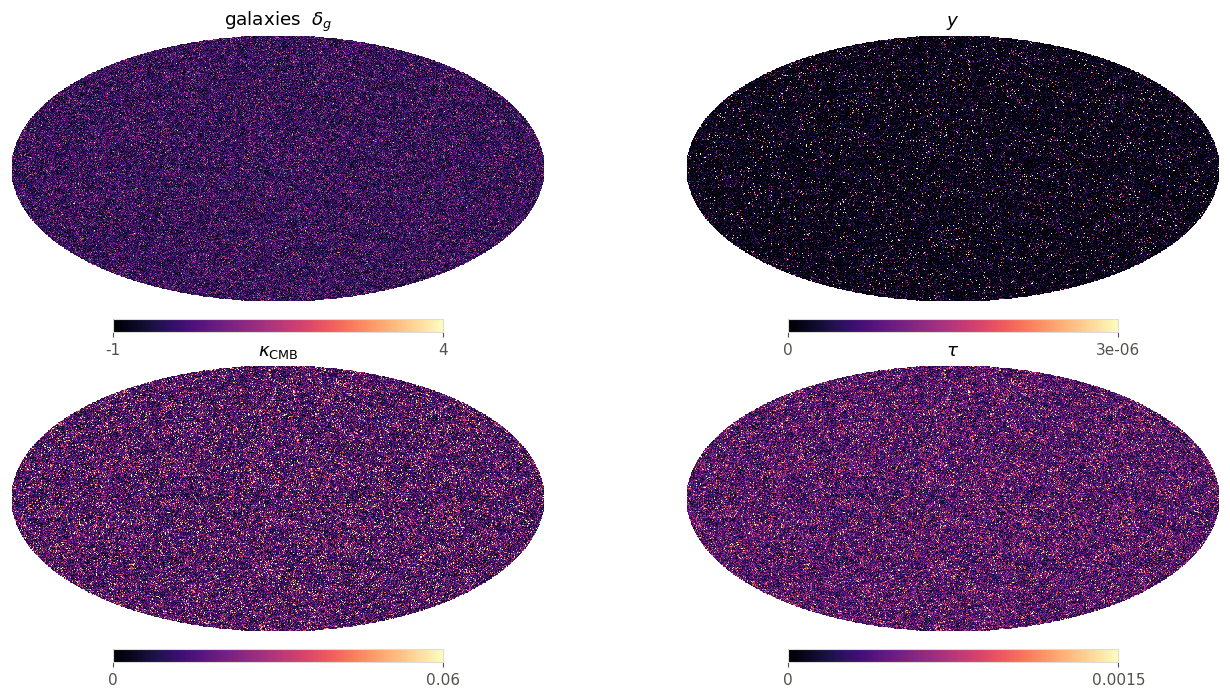

In [8]:
# Full sky, to show the footprint the three probes actually cover.
fig = plt.figure(figsize=(13.5, 6.6))
for idx, (m, title, vmin, vmax) in enumerate(panels, start=1):
    hp.mollview(m, min=vmin, max=vmax, title=title, cbar=True, notext=True,
                cmap="magma", sub=(2, 2, idx), fig=fig.number)

## 4. The 128 design points

Drawn from the round-1 proposal mixture (built from the theory-SBI posterior), shown as
open circles over the same theory HMC / theory SBI contours.

128 design points


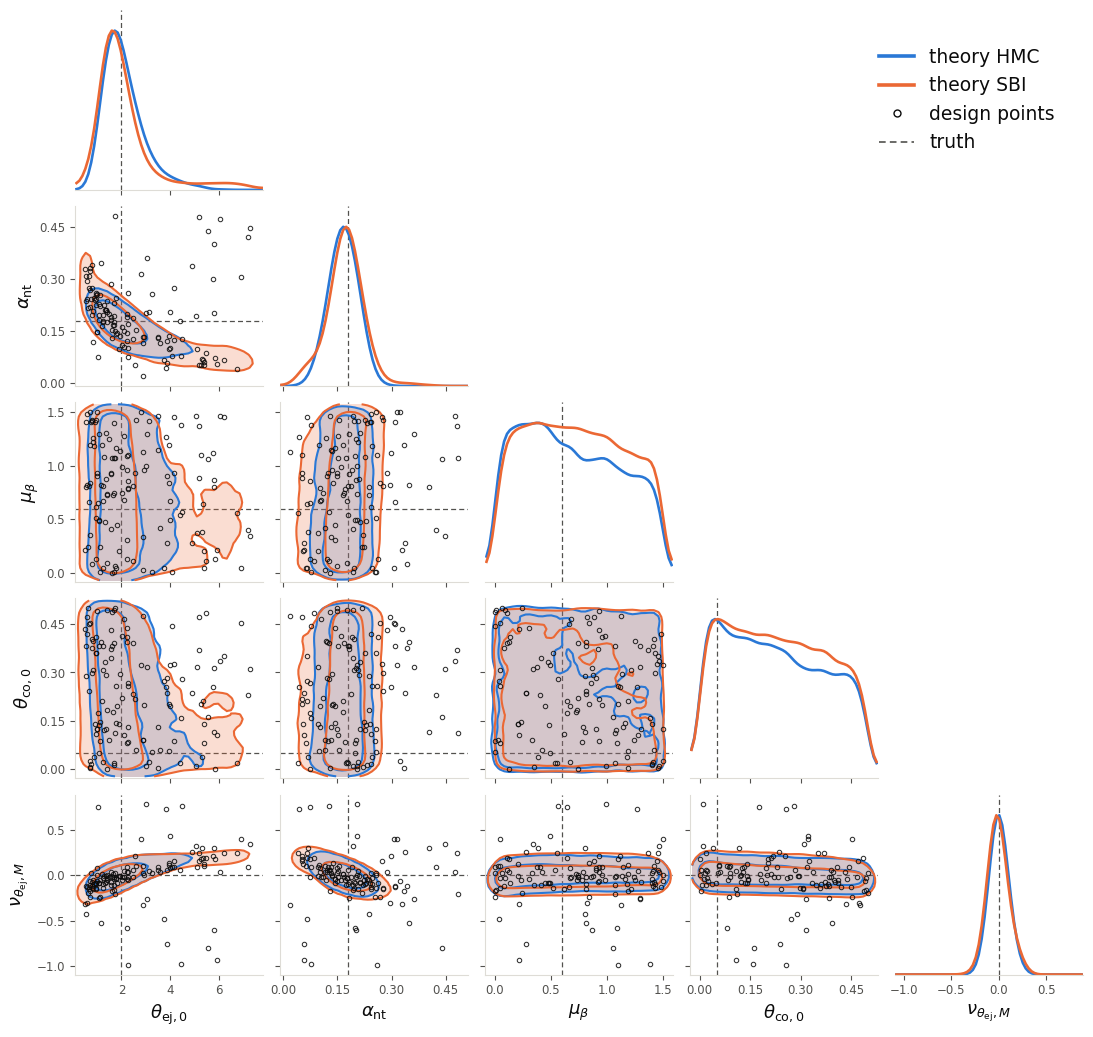

In [9]:
plan = json.loads((MSBI / "paste_plan/round_1/paste_plan.json").read_text())
design = np.array([[e["theta"][p] for p in PARAMS] for e in plan["entries"]], float)
print(f"{design.shape[0]} design points")

_ = triangle([hmc, npe], [BLUE, ORANGE], ["theory HMC", "theory SBI"], points=design)

## 5. All three posteriors

mock SBI is NLE trained on the pasted-map simulator, evaluated on the noiseless pasted mock
observation. This is the 94-point trial, not the full 128-point round.

mock SBI 80,000 samples from 94 pasted points x 64 noise draws, 4 pooled seeds


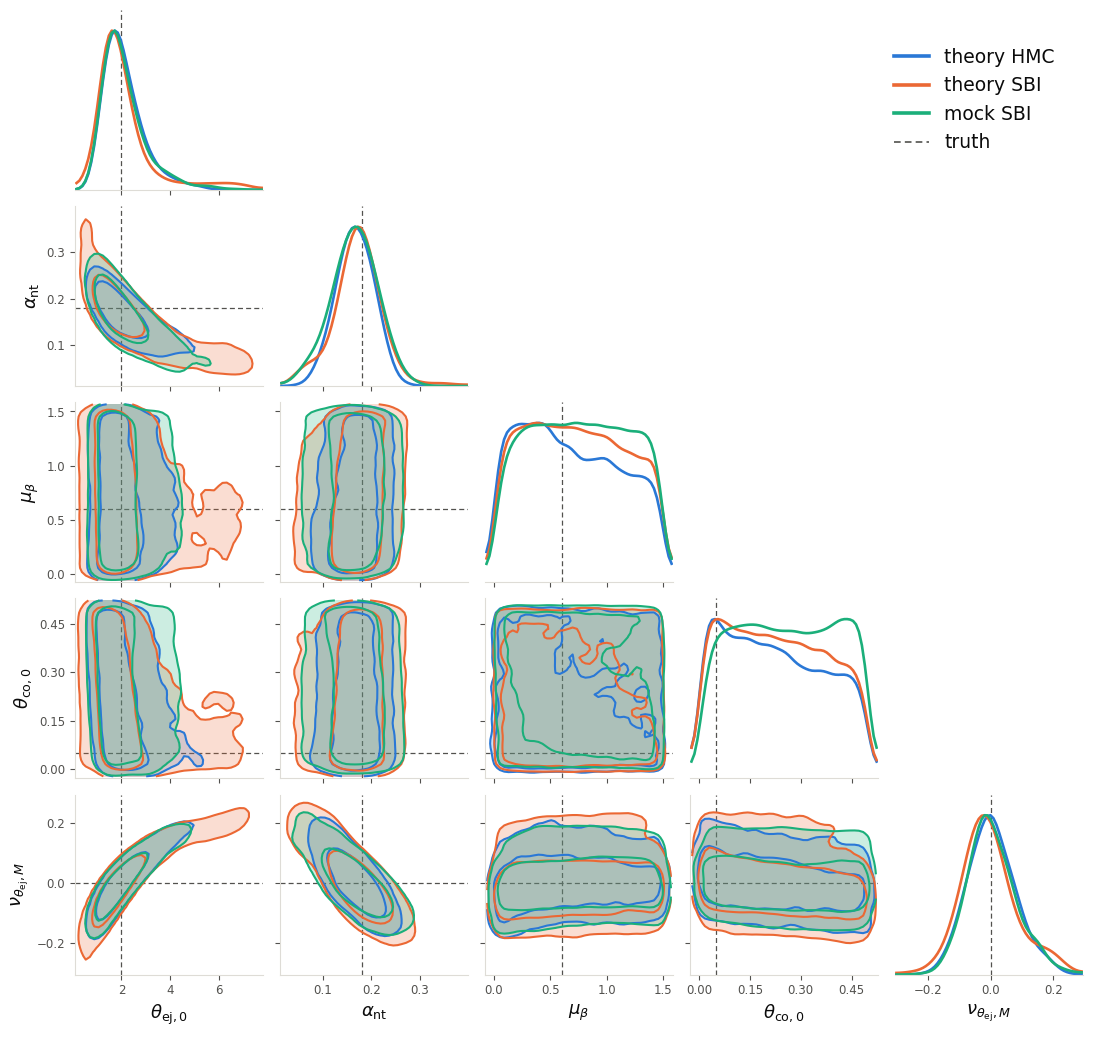

In [10]:
MOCK = MSBI / "trial/mock_snle_n0038_posterior.npz"
mock_npz = np.load(MOCK, allow_pickle=True)
mock = np.asarray(mock_npz["theta"])
man  = json.loads(str(mock_npz["manifest_json"]))
print(f"mock SBI {mock.shape[0]:,} samples from {man['n_pasted_points']} pasted points "
      f"x {man['n_training_rows'] // man['n_pasted_points']} noise draws, "
      f"{man['seeds']} pooled seeds")

_ = triangle([hmc, npe, mock], [BLUE, ORANGE, GREEN],
             ["theory HMC", "theory SBI", "mock SBI"])

In [11]:
# Mean drift and 90% width ratio against theory HMC, in probit units.
u_hmc  = np.asarray(hraw["u"]).reshape(-1, 5)
u_npe  = np.asarray(np.load(INF / "sbi_sc/run01/posterior_samples_round_4.npz")["u"])
u_mock = np.asarray(mock_npz["u"])
w90 = lambda x: np.percentile(x, 95, axis=0) - np.percentile(x, 5, axis=0)
print(f"{'parameter':<16}{'SBI drift':>11}{'SBI w90':>9}{'mock drift':>12}{'mock w90':>10}")
for j, p in enumerate(PARAMS):
    print(f"{p:<16}"
          f"{(u_npe[:, j].mean()  - u_hmc[:, j].mean()) / u_hmc[:, j].std(ddof=1):>+11.3f}"
          f"{w90(u_npe)[j]  / w90(u_hmc)[j]:>9.3f}"
          f"{(u_mock[:, j].mean() - u_hmc[:, j].mean()) / u_hmc[:, j].std(ddof=1):>+12.3f}"
          f"{w90(u_mock)[j] / w90(u_hmc)[j]:>10.3f}")

parameter         SBI drift  SBI w90  mock drift  mock w90
theta_ej_0           -0.075    1.547      +0.014     1.086
alpha_nt             +0.089    1.415      -0.074     1.340
mu_beta              +0.105    0.977      +0.175     0.945
theta_co_0           +0.042    0.982      +0.233     0.964
nu_theta_ej_M        -0.130    1.223      +0.021     1.025
